In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
df = pd.read_csv(r"C:\Users\ASUS\Downloads\train.txt\train.txt", sep= ';', header= None, names = ['text', 'emotion'])

In [3]:
df

,text,emotion
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger
...,...,...
15995,i just had a very brief time in the beanbag an...,sadness
15996,i am now turning and i feel pathetic that i am...,sadness
15997,i feel strong and good overall,joy
15998,i feel like this was such a rude comment and i...,anger


In [4]:
df.head()

,text,emotion
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [5]:
df.isna().sum()

text       0
emotion    0
dtype: int64

In [6]:
unique_emotion = df['emotion'].unique()
emotion_number = {}
i = 0
for emo in unique_emotion:
    emotion_number[emo] = i
    i += 1
df['emotion'] = df['emotion'].map(emotion_number)

In [7]:
df.head()

,text,emotion
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,1
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,1


In [8]:
emotion_number

{'sadness': 0, 'anger': 1, 'love': 2, 'surprise': 3, 'fear': 4, 'joy': 5}

In [9]:
df['text'] = df['text'].apply(lambda x : x.lower())

In [10]:
import string
def remove_punc(txt):
    return txt.translate(str.maketrans('', '', string.punctuation))

In [11]:
df['text'] = df['text'].apply(remove_punc)

In [12]:
def remove_numbers(txt):
    new = ""
    for i in txt:
        if not i.isdigit():
            new = new + i
    return new
df['text'] = df['text'].apply(remove_numbers)

In [13]:
def remove_emoji(txt): 
    new = ""
    for i in txt:
        if i.isascii():
            new += i 
    return new 
df['text'] = df['text'].apply(remove_emoji)

In [14]:
!pip install nltk

In [15]:
import nltk

In [16]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

In [17]:
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [18]:
stopwords = set(stopwords.words('english'))
stopwords

{'a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 "he's",
 'her',
 'here',
 'hers',
 'herself',
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 "i'll",
 "i'm",
 "i've",
 'if',
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [19]:
df.loc[1]['text']

'i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake'

In [20]:
def remove(txt):
    words = txt.split()
    cleaned_text = []
    for i in words:
        if not i in stopwords:
            cleaned_text.append(i)
    return ' '.join(cleaned_text)



df['text'] = df['text'].apply(remove)

In [21]:
df.loc[1]['text']

'go feeling hopeless damned hopeful around someone cares awake'

In [22]:
from sklearn.model_selection import train_test_split

In [23]:
X_train, X_test, y_train, y_test = train_test_split(df['text'], df['emotion'], test_size=0.20, random_state=42)

In [24]:
X_test

8756                             ive made week feel beaten
4660                              feel strategy worthwhile
6095                     feel worthless weak say want find
304                                        feel clever nov
8241                      im moved ive feeling kind gloomy
                               ...                        
15578    feel useful pulpit find ironic often question ...
5746             dried bladders ready day im feeling brave
6395                             feel thrilled matter days
7624     woke morning text mr c declaring walking work ...
15245                                            feel dumb
Name: text, Length: 3200, dtype: object

In [25]:
X_train

676      refers course though cant help feeling somehow...
12113                im starting feel im suffering fatigue
7077     feel like probably would liked book little bit...
13005                                  really feel awkward
12123    im feeling little grumpy today lame weather te...
                               ...                        
13418    love leave reader feeling confused slightly de...
5390                                         feel delicate
860                          starting feel little stressed
15795             feel stressed tired worn shape neglected
7270         feel someone rude wrongly done something lose
Name: text, Length: 12800, dtype: object

In [26]:
df.shape

(16000, 2)

In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

In [28]:
bow_vectorizer = CountVectorizer()


In [29]:
X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)

In [30]:
X_train_bow

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 116059 stored elements and shape (12800, 13361)>

In [31]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

In [32]:
nb_model = MultinomialNB()

In [33]:
nb_model.fit(X_train_bow, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [34]:
pred_nb = nb_model.predict(X_test_bow)

In [35]:
print(accuracy_score(y_test, pred_nb))

0.768125


In [36]:
print(classification_report(y_test, pred_nb))

              precision    recall  f1-score   support

           0       0.75      0.95      0.84       946
           1       0.89      0.63      0.74       427
           2       0.93      0.27      0.41       296
           3       1.00      0.05      0.10       113
           4       0.85      0.57      0.68       397
           5       0.73      0.96      0.83      1021

    accuracy                           0.77      3200
   macro avg       0.86      0.57      0.60      3200
weighted avg       0.80      0.77      0.74      3200



In [37]:
tfid_vectorizer = TfidfVectorizer()

In [38]:
X_train_tfid = tfid_vectorizer.fit_transform(X_train)
X_test_tfid = tfid_vectorizer.transform(X_test)

In [39]:
nb_model2 = MultinomialNB()

In [40]:
nb_model2.fit(X_train_tfid, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [41]:
pred_tfid = nb_model2.predict(X_test_tfid)

In [42]:
print(accuracy_score(y_test, pred_tfid))

0.6609375


In [43]:
print(classification_report(y_test, pred_tfid))

              precision    recall  f1-score   support

           0       0.70      0.93      0.80       946
           1       0.93      0.29      0.44       427
           2       1.00      0.03      0.06       296
           3       1.00      0.01      0.02       113
           4       0.92      0.22      0.36       397
           5       0.60      0.99      0.74      1021

    accuracy                           0.66      3200
   macro avg       0.86      0.41      0.40      3200
weighted avg       0.76      0.66      0.58      3200



In [44]:
from sklearn.linear_model import LogisticRegression

In [45]:
model_lr = LogisticRegression(max_iter=1000)

In [46]:
model_lr.fit(X_train_tfid, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [47]:
y_pred_lr = model_lr.predict(X_test_tfid)

In [48]:
print(accuracy_score(y_test, y_pred_lr))

0.8628125


In [49]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.90      0.94      0.92       946
           1       0.90      0.81      0.86       427
           2       0.90      0.61      0.73       296
           3       0.88      0.47      0.61       113
           4       0.86      0.76      0.81       397
           5       0.81      0.96      0.88      1021

    accuracy                           0.86      3200
   macro avg       0.88      0.76      0.80      3200
weighted avg       0.87      0.86      0.86      3200



In [50]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),   # unigram + bigram 🔥
    min_df=2,
    max_df=0.9,
    sublinear_tf=True
)

X_train_tfid = tfidf.fit_transform(X_train)
X_test_tfid = tfidf.transform(X_test)

In [51]:
from sklearn.model_selection import GridSearchCV

In [52]:
from sklearn.linear_model import LogisticRegression

param_grid_lr = {
    'C': [0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'liblinear']
}

grid_lr = GridSearchCV(LogisticRegression(max_iter=2000),
                       param_grid_lr,
                       cv=3,
                       n_jobs=-1)

grid_lr.fit(X_train_tfid, y_train)

print("Best Params:", grid_lr.best_params_)

y_pred = grid_lr.predict(X_test_tfid)

C:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


Best Params: {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}


In [53]:
print(accuracy_score(y_test, y_pred))

0.89875


In [54]:
from sklearn.naive_bayes import MultinomialNB

param_grid_nb = {
    'alpha': [0.1, 0.5, 1.0]
}

grid_nb = GridSearchCV(MultinomialNB(),
                       param_grid_nb,
                       cv=3)

grid_nb.fit(X_train_tfid, y_train)

,estimator,MultinomialNB()
,param_grid,"{'alpha': [0.1, 0.5, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,0.1


In [55]:
from sklearn.svm import LinearSVC

param_grid_svm = {
    'C': [0.1, 1, 10]
}

grid_svm = GridSearchCV(LinearSVC(),
                        param_grid_svm,
                        cv=3,
                        n_jobs=-1)

grid_svm.fit(X_train_tfid, y_train)

y_pred_svm = grid_svm.predict(X_test_tfid)

In [56]:
print(accuracy_score(y_test, y_pred_svm))

0.9009375


In [57]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', LogisticRegression(max_iter=2000))
])

param_grid = {
    'tfidf__max_features': [3000, 5000],
    'tfidf__ngram_range': [(1,1), (1,2)],
    'clf__C': [0.1, 1, 10]
}

grid = GridSearchCV(pipeline, param_grid, cv=3, n_jobs=-1)

grid.fit(X_train, y_train)

print(grid.best_params_)

{'clf__C': 10, 'tfidf__max_features': 5000, 'tfidf__ngram_range': (1, 2)}


In [58]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

results = []

def evaluate_model(name, y_test, y_pred):
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='weighted'),
        "Recall": recall_score(y_test, y_pred, average='weighted'),
        "F1 Score": f1_score(y_test, y_pred, average='weighted')
    })

# Add your models here
evaluate_model("Naive Bayes (BoW)", y_test, pred_nb)
evaluate_model("Naive Bayes (TF-IDF)", y_test, pred_tfid)
evaluate_model("Logistic Regression", y_test, y_pred_lr)

# After SVM
evaluate_model("SVM", y_test, y_pred_svm)

df_results = pd.DataFrame(results)
print(df_results)

                  Model  Accuracy  Precision    Recall  F1 Score
0     Naive Bayes (BoW)  0.768125   0.799918  0.768125  0.737296
1  Naive Bayes (TF-IDF)  0.660937   0.762364  0.660937  0.582596
2   Logistic Regression  0.862812   0.867114  0.862812  0.857403
3                   SVM  0.900937   0.900108  0.900937  0.899915


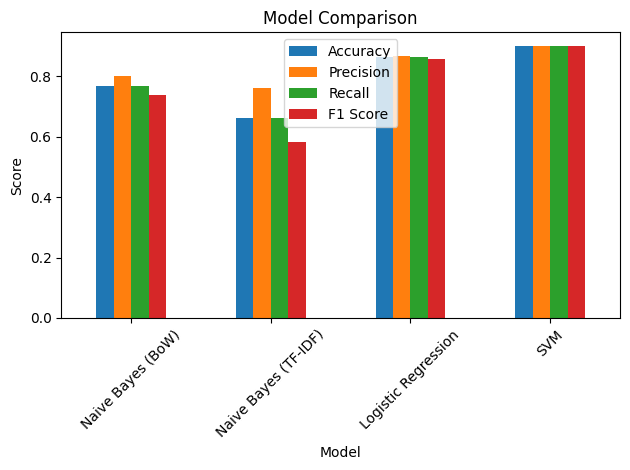

In [59]:
import matplotlib.pyplot as plt

df_results.set_index("Model").plot(kind="bar")
plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

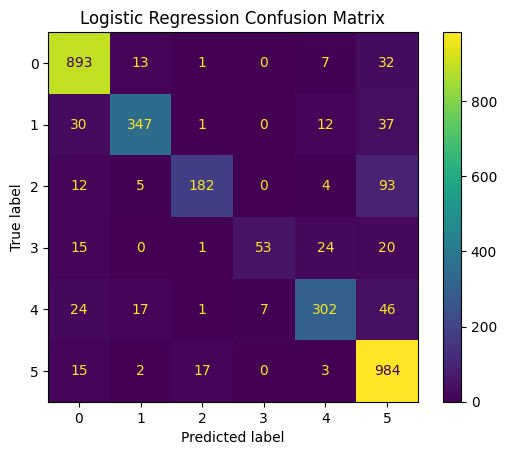

In [60]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr)
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [61]:
best_model = df_results.sort_values(by="Accuracy", ascending=False)
print(best_model)

                  Model  Accuracy  Precision    Recall  F1 Score
3                   SVM  0.900937   0.900108  0.900937  0.899915
2   Logistic Regression  0.862812   0.867114  0.862812  0.857403
0     Naive Bayes (BoW)  0.768125   0.799918  0.768125  0.737296
1  Naive Bayes (TF-IDF)  0.660937   0.762364  0.660937  0.582596


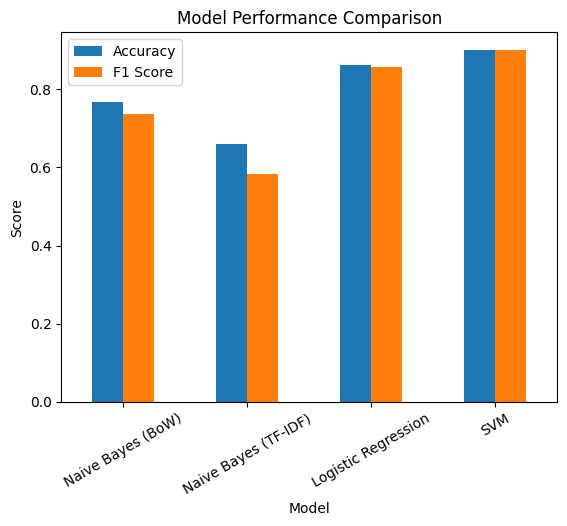

In [62]:
df_results.set_index("Model")[["Accuracy","F1 Score"]].plot(kind="bar")
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=30)
plt.show()

In [63]:
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

lr = LogisticRegression(max_iter=2000)
nb = MultinomialNB()
svm = LinearSVC()

voting_clf = VotingClassifier(
    estimators=[
        ('lr', lr),
        ('nb', nb),
        ('svm', svm)
    ],
    voting='hard'   # use 'soft' if all models support predict_proba
)

voting_clf.fit(X_train_tfid, y_train)

y_pred_vote = voting_clf.predict(X_test_tfid)

In [64]:
print(accuracy_score(y_test, y_pred_vote))

0.875


In [65]:
evaluate_model("Voting Ensemble", y_test, y_pred_vote)

In [66]:
from sklearn.svm import SVC

svm = SVC(probability=True)

In [67]:
voting='soft'

In [68]:
from sklearn.ensemble import StackingClassifier

estimators = [
    ('lr', LogisticRegression(max_iter=2000)),
    ('nb', MultinomialNB()),
    ('svm', LinearSVC())
]

stack_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression()
)

stack_model.fit(X_train_tfid, y_train)

y_pred_stack = stack_model.predict(X_test_tfid)

In [69]:
print(accuracy_score(y_test, y_pred_stack))

0.9059375


In [70]:
import pickle

# save best model (stacking)
pickle.dump(stack_model, open("model.pkl", "wb"))

# save vectorizer
pickle.dump(tfidf, open("tfidf.pkl", "wb"))

# save label mapping
emotion_map = {0:'sadness', 1:'anger', 2:'love', 3:'surprise', 4:'fear', 5:'joy'}
pickle.dump(emotion_map, open("label_map.pkl", "wb"))

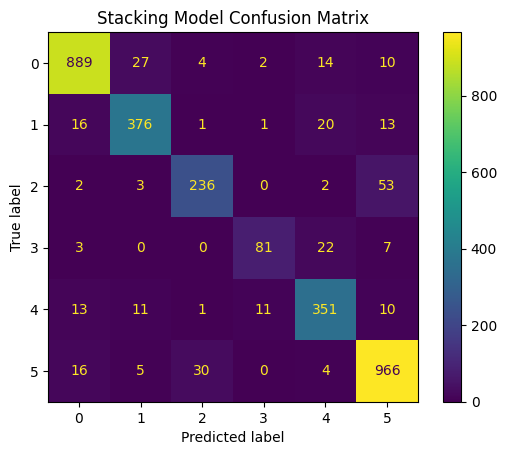

In [71]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_stack)

plt.title("Stacking Model Confusion Matrix")
plt.show()

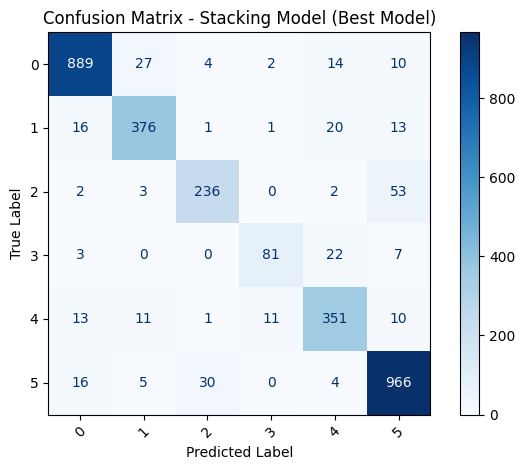

In [72]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred_stack,
    cmap="Blues",
    xticks_rotation=45
)

plt.title("Confusion Matrix - Stacking Model (Best Model)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

In [73]:
plt.savefig("stacking_confusion_matrix.png")

<Figure size 640x480 with 0 Axes>